# DeepSense 6G Multimodal V2V Beam Tracking
## Exploratory Data Analysis (EDA) with Model-Annotated Predictions

This notebook loads and analyzes the complete annotated dataset containing ground-truth multimodal sensor streams (GPS kinematics, 256-beam phased array RF powers, camera images) and predictions from the trained **`P3_MultiTaskProfile`** model.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120

# Load annotated dataset
csv_path = 'data/processed/annotated_scenario36_with_predictions.csv'
df = pd.read_csv(csv_path)
print(f'Loaded annotated dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head()

Loaded annotated dataset: 24,179 rows, 28 columns


,split,traj_id,seq_index,y_frame_idx,rgb_path,dist_m,rel_east_m,rel_north_m,speed_mps,heading_deg,true_best_beam,optimal_power_db,pred_best_beam_top1,pred_top3_beams,pred_top5_beams,pred_top13_beams,is_top1_correct,is_top3_correct,is_top5_correct,is_top13_correct,beam_index_error,predicted_beam_power_db,power_loss_db,profile_mae_db,profile_rmse_db,profile_rank_corr,conformal_set_size,conformal_is_covered
0,train,1,1,5,unit1/rgb5/frame_11-46-31.706323.jpg,0.0,0.0,0.0,0.0,0.0,161,-3.863259,161,"[161, 162, 160]","[161, 162, 160, 163, 158]","[161, 162, 160, 163, 158, 159, 144, 164, 156, 150, 140, 143, 142]",True,True,True,True,0,-3.863259,0.000000,1.065075,1.498763,0.873581,8,True
1,train,1,1,6,unit1/rgb5/frame_11-46-31.806424.jpg,0.0,0.0,0.0,0.0,0.0,162,-4.073646,161,"[161, 162, 160]","[161, 162, 160, 163, 158]","[161, 162, 160, 163, 158, 159, 144, 164, 156, 150, 140, 143, 142]",False,True,True,True,1,-4.322013,0.248367,0.998252,1.423003,0.883857,8,True
2,train,1,1,7,unit1/rgb5/frame_11-46-31.906525.jpg,0.0,0.0,0.0,0.0,0.0,161,-4.023491,161,"[161, 162, 160]","[161, 162, 160, 163, 158]","[161, 162, 160, 163, 158, 159, 144, 164, 156, 150, 140, 143, 142]",True,True,True,True,0,-4.023491,0.000000,0.954738,1.379671,0.889558,8,True
3,train,1,1,8,unit1/rgb5/frame_11-46-32.006626.jpg,0.0,0.0,0.0,0.0,0.0,162,-4.054249,161,"[161, 162, 160]","[161, 162, 160, 163, 158]","[161, 162, 160, 163, 158, 159, 144, 164, 156, 150, 140, 143, 142]",False,True,True,True,1,-4.061988,0.007739,1.018257,1.455022,0.881420,8,True
4,train,1,1,9,unit1/rgb5/frame_11-46-32.106727.jpg,0.0,0.0,0.0,0.0,0.0,161,-3.911155,161,"[161, 162, 160]","[161, 162, 160, 163, 158]","[161, 162, 160, 163, 158, 159, 144, 164, 156, 150, 140, 143, 142]",True,True,True,True,0,-3.911155,0.000000,1.030150,1.507536,0.878520,8,True


### 1. Partition-Wise Summary Statistics

In [2]:
summary = df.groupby('split').agg({
    'traj_id': 'nunique',
    'seq_index': 'count',
    'is_top1_correct': lambda x: f'{np.mean(x)*100:.2f}%',
    'is_top3_correct': lambda x: f'{np.mean(x)*100:.2f}%',
    'is_top5_correct': lambda x: f'{np.mean(x)*100:.2f}%',
    'is_top13_correct': lambda x: f'{np.mean(x)*100:.2f}%',
    'power_loss_db': lambda x: f'{np.mean(x):.2f} dB',
    'profile_mae_db': lambda x: f'{np.mean(x):.2f} dB',
    'conformal_set_size': lambda x: f'{np.mean(x):.1f} beams'
}).rename(columns={
    'traj_id': 'Trajectories',
    'seq_index': 'Sequences',
    'is_top1_correct': 'Top-1 Acc',
    'is_top3_correct': 'Top-3 Acc',
    'is_top5_correct': 'Top-5 Acc',
    'is_top13_correct': 'Top-13 Acc',
    'power_loss_db': 'Mean APL',
    'profile_mae_db': 'Profile MAE',
    'conformal_set_size': 'Mean Conf Set Size'
}).loc[['train', 'val', 'calib', 'test']]
summary

,Trajectories,Sequences,Top-1 Acc,Top-3 Acc,Top-5 Acc,Top-13 Acc,Mean APL,Profile MAE,Mean Conf Set Size
split,,,,,,,,,
train,68,13260,75.35%,96.44%,97.68%,99.25%,0.30 dB,1.21 dB,17.6 beams
val,19,3705,15.71%,34.71%,45.78%,60.13%,10.67 dB,2.39 dB,16.1 beams
calib,19,3705,6.91%,18.54%,28.26%,51.98%,4.47 dB,1.86 dB,21.5 beams
test,18,3509,1.65%,5.27%,11.37%,40.55%,16.83 dB,3.47 dB,13.9 beams


### 2. Beam Alignment & Power Loss Distribution

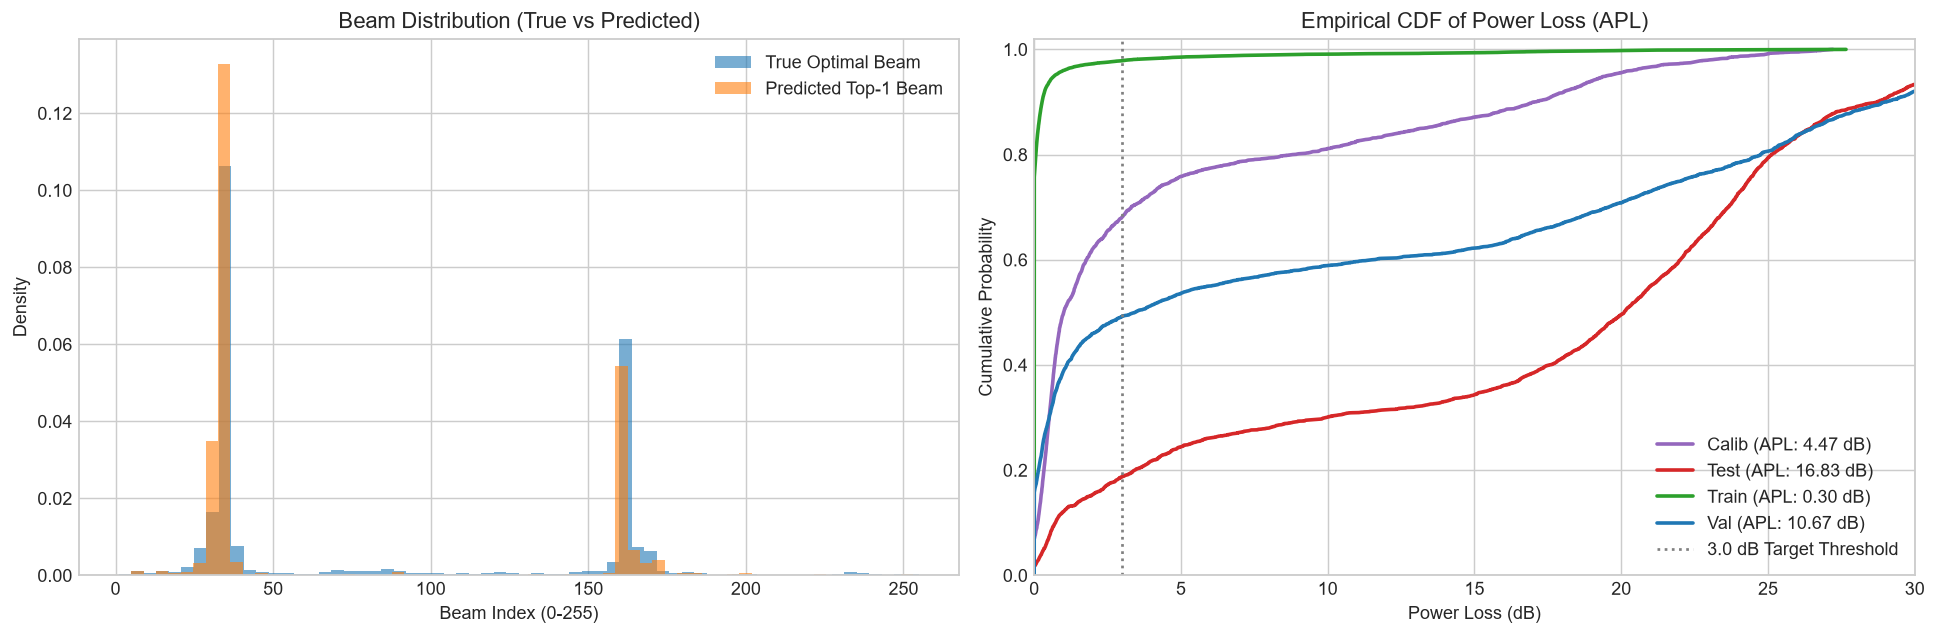

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Beam index histogram
axes[0].hist(df['true_best_beam'], bins=64, alpha=0.6, color='#1f77b4', label='True Optimal Beam', density=True)
axes[0].hist(df['pred_best_beam_top1'], bins=64, alpha=0.6, color='#ff7f0e', label='Predicted Top-1 Beam', density=True)
axes[0].set_title('Beam Distribution (True vs Predicted)')
axes[0].set_xlabel('Beam Index (0-255)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Right: Power Loss ECDF
colors = {'train': '#2ca02c', 'val': '#1f77b4', 'calib': '#9467bd', 'test': '#d62728'}
for split_name, sub in df.groupby('split'):
    losses = np.sort(sub['power_loss_db'])
    cdf = np.arange(1, len(losses)+1) / len(losses)
    axes[1].plot(losses, cdf, label=f'{split_name.capitalize()} (APL: {sub["power_loss_db"].mean():.2f} dB)', color=colors.get(split_name, 'gray'), linewidth=2)
axes[1].axvline(3.0, color='gray', linestyle=':', label='3.0 dB Target Threshold')
axes[1].set_xlim(0, 30)
axes[1].set_ylim(0, 1.02)
axes[1].set_title('Empirical CDF of Power Loss (APL)')
axes[1].set_xlabel('Power Loss (dB)')
axes[1].set_ylabel('Cumulative Probability')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3. Model Accuracy Across Physical Kinematic Regimes (Distance & Speed)

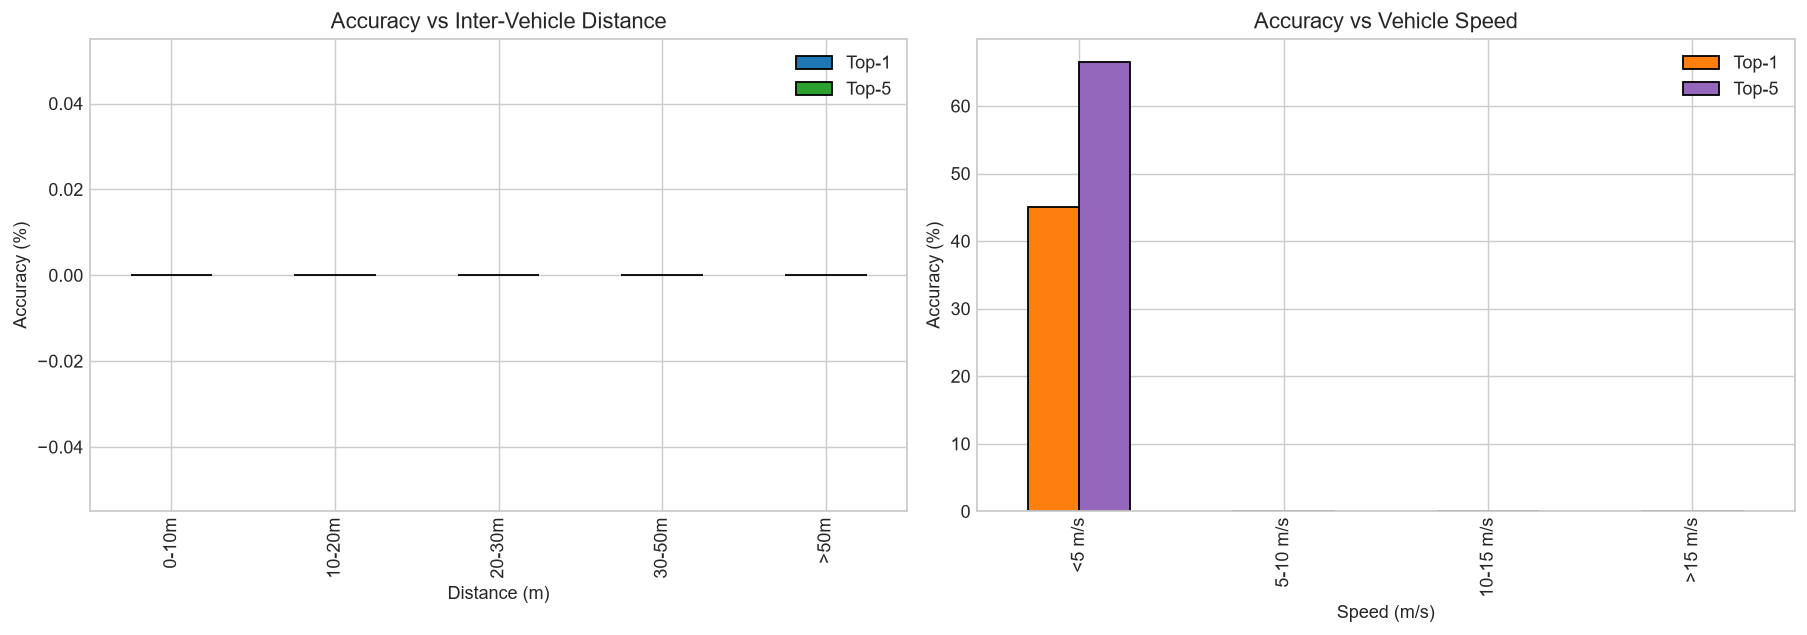

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['dist_bin'] = pd.cut(df['dist_m'], bins=[0, 10, 20, 30, 50, 100], labels=['0-10m', '10-20m', '20-30m', '30-50m', '>50m'])
dist_perf = df.groupby('dist_bin', observed=False)[['is_top1_correct', 'is_top5_correct']].mean() * 100
dist_perf.plot(kind='bar', ax=axes[0], color=['#1f77b4', '#2ca02c'], edgecolor='black')
axes[0].set_title('Accuracy vs Inter-Vehicle Distance')
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(['Top-1', 'Top-5'])

df['speed_bin'] = pd.cut(df['speed_mps'], bins=[-1, 5, 10, 15, 25], labels=['<5 m/s', '5-10 m/s', '10-15 m/s', '>15 m/s'])
speed_perf = df.groupby('speed_bin', observed=False)[['is_top1_correct', 'is_top5_correct']].mean() * 100
speed_perf.plot(kind='bar', ax=axes[1], color=['#ff7f0e', '#9467bd'], edgecolor='black')
axes[1].set_title('Accuracy vs Vehicle Speed')
axes[1].set_xlabel('Speed (m/s)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(['Top-1', 'Top-5'])

plt.tight_layout()
plt.show()

### 4. Interactive Chronological Trajectory Visualizer
Select any trajectory run to visualize live beam tracking and received power over time.

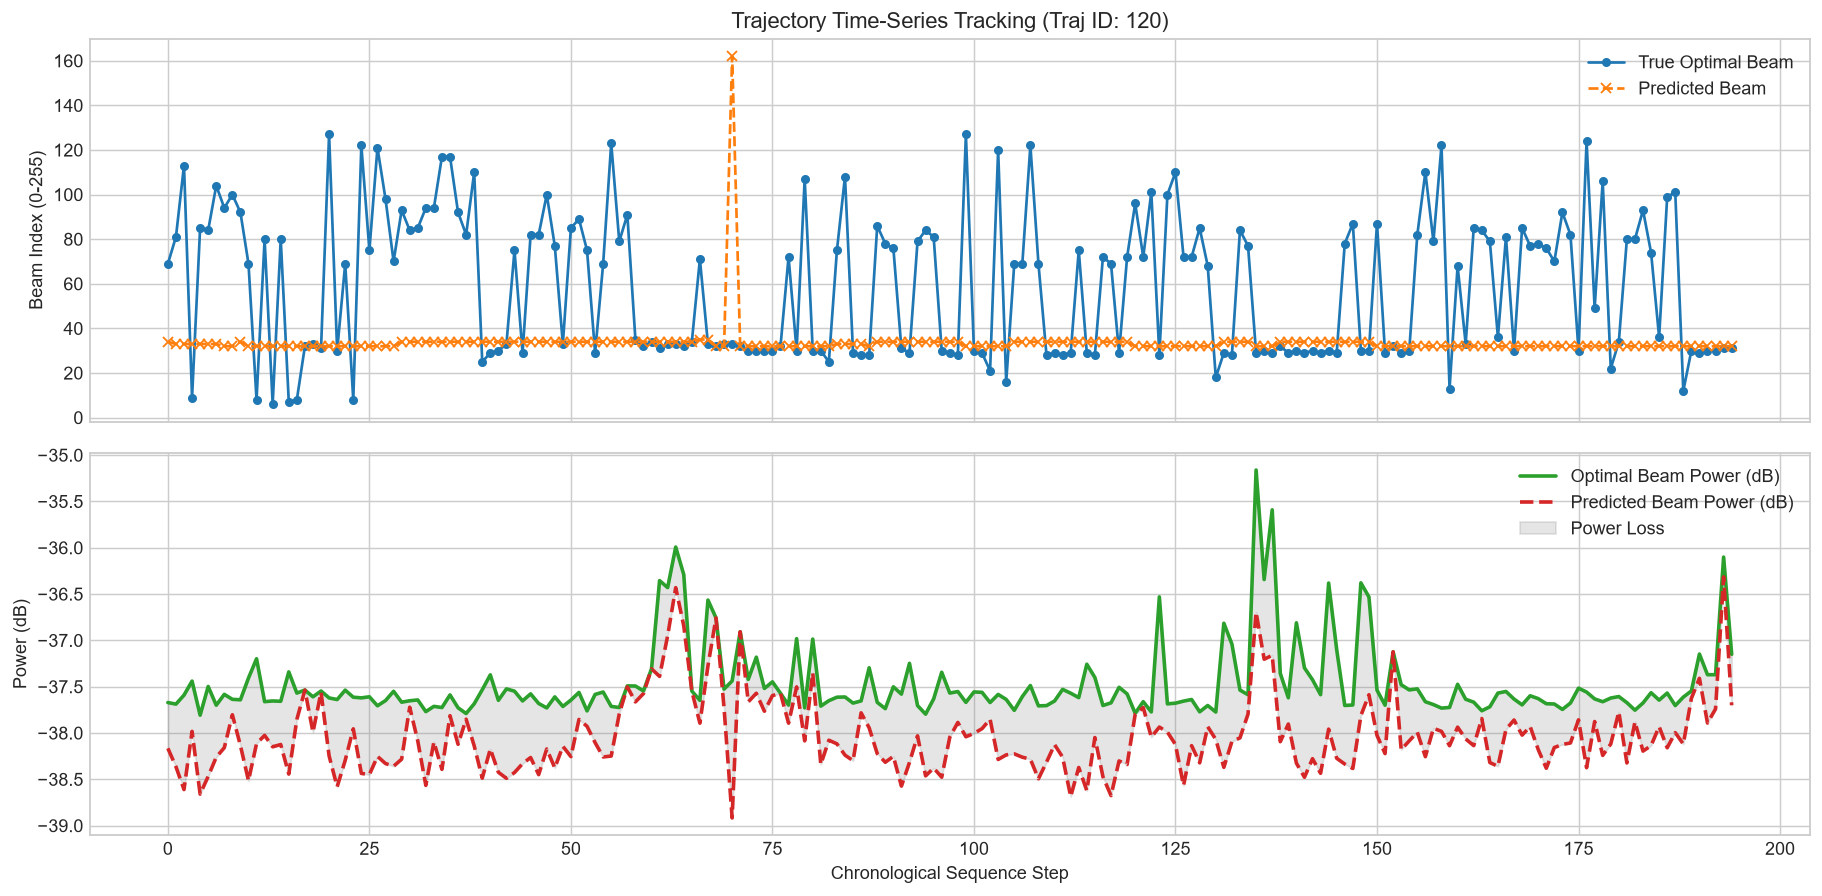

In [5]:
sample_traj = df[df['split'] == 'test']['traj_id'].iloc[0]
traj_sub = df[df['traj_id'] == sample_traj].sort_values('seq_index')

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(range(len(traj_sub)), traj_sub['true_best_beam'], label='True Optimal Beam', color='#1f77b4', marker='o', markersize=4)
axes[0].plot(range(len(traj_sub)), traj_sub['pred_best_beam_top1'], label='Predicted Beam', color='#ff7f0e', marker='x', markersize=5, linestyle='--')
axes[0].set_ylabel('Beam Index (0-255)')
axes[0].set_title(f'Trajectory Time-Series Tracking (Traj ID: {sample_traj})')
axes[0].legend()

axes[1].plot(range(len(traj_sub)), traj_sub['optimal_power_db'], label='Optimal Beam Power (dB)', color='#2ca02c', linewidth=2)
axes[1].plot(range(len(traj_sub)), traj_sub['predicted_beam_power_db'], label='Predicted Beam Power (dB)', color='#d62728', linestyle='--', linewidth=2)
axes[1].fill_between(range(len(traj_sub)), traj_sub['predicted_beam_power_db'], traj_sub['optimal_power_db'], color='gray', alpha=0.2, label='Power Loss')
axes[1].set_xlabel('Chronological Sequence Step')
axes[1].set_ylabel('Power (dB)')
axes[1].legend()

plt.tight_layout()
plt.show()